# Class Brews Visualizers

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lisyderm/brew_validator/blob/main/visualizer/us_ww_breweries_map.ipynb)

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="white")

In [2]:
# local copy of usbrews.json
with open("usbrews.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

places = raw_data.get("places", [])
df = pd.DataFrame(places)

# Convert coordinate and elevation fields to numeric floats
df["latitude"] = pd.to_numeric(df["latitude"], errors="coerce")
df["longitude"] = pd.to_numeric(df["longitude"], errors="coerce")
df["elevation"] = pd.to_numeric(df["elevation"], errors="coerce")

# Drop any rows with missing coordinates or elevation
df = df.dropna(subset=["latitude", "longitude", "elevation"])

print(f"Successfully loaded {len(df)} valid brewery coordinates!")
print(df)

Successfully loaded 149 valid brewery coordinates!
                  id team                               name municipality  \
0           lisyderm  t13         Folklore Brewing & Meadery       Dothan   
1        PokeDan0928  t38                 Green Bus Brewings   Huntsville   
2            Dami359  t38                Common Bond Brewers   Montgomery   
3      mattboersma18  t22          Anchorage Brewing Company    Anchorage   
4          Obinna992  t38           Dark Sky Brewing Company          NaN   
..               ...  ...                                ...          ...   
144            CFRPI  t20              First Mile Brewing Co    Fort Kent   
145            31773  t17  Lexington Brewing & Distilling Co    Lexington   
146  ColeRechsteiner  t15        Scratchtown Brewing Company          Ord   
147    voncowenhoven  t33        Grand Teton Brewing Company       Victor   
148        Just-Sean  t11   One Eyed Buffalo Brewing Company  Thermopolis   

       region   latitude

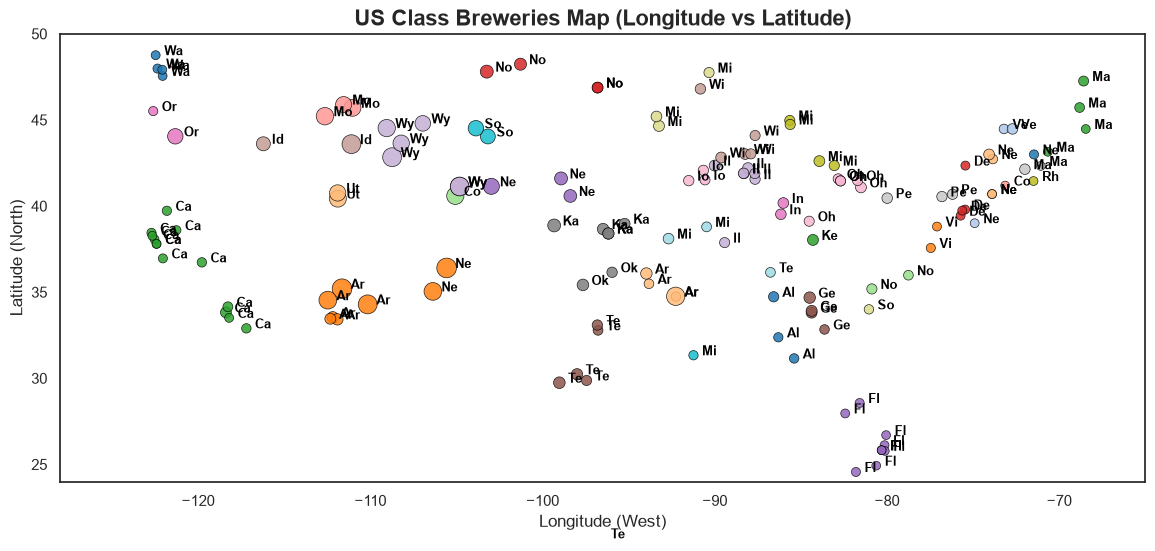

In [3]:
plt.figure(figsize=(14, 8))

valid_us = (
    (df['latitude'] >= 18.0) & 
    (df['latitude'] <= 72.0) & 
    (df['longitude'] >= -180.0) & 
    (df['longitude'] <= -65.0)
)

df_valid = df[valid_us]


ax = sns.scatterplot(
    data=df,
    x="longitude",
    y="latitude",
    hue="region",
    size="elevation",
    sizes=(40, 200),
    palette="tab20",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5,
    legend=False,
)

for _, row in df_valid.iterrows():
    label_text = f"{row['region'][:2]}"
    plt.text(
        row['longitude'] + 0.5,  # offset from marker
        row['latitude'], 
        label_text, 
        fontsize=9, 
        fontweight='bold', 
        color='black',
    )

plt.title(
    "US Class Breweries Map (Longitude vs Latitude)", fontsize=16, fontweight="bold"
)
plt.xlabel("Longitude (West)", fontsize=12)
plt.ylabel("Latitude (North)", fontsize=12)

# contiguous US only
plt.xlim(-128, -65)
plt.ylim(24, 50)

# Make the map proportions look natural (aspect ratio adjustment)
ax.set_aspect("equal")

# Move the legend outside or clean it up if it gets too crowded with 50 states
# plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0, ncol=2)
# plt.tight_layout()

plt.show()

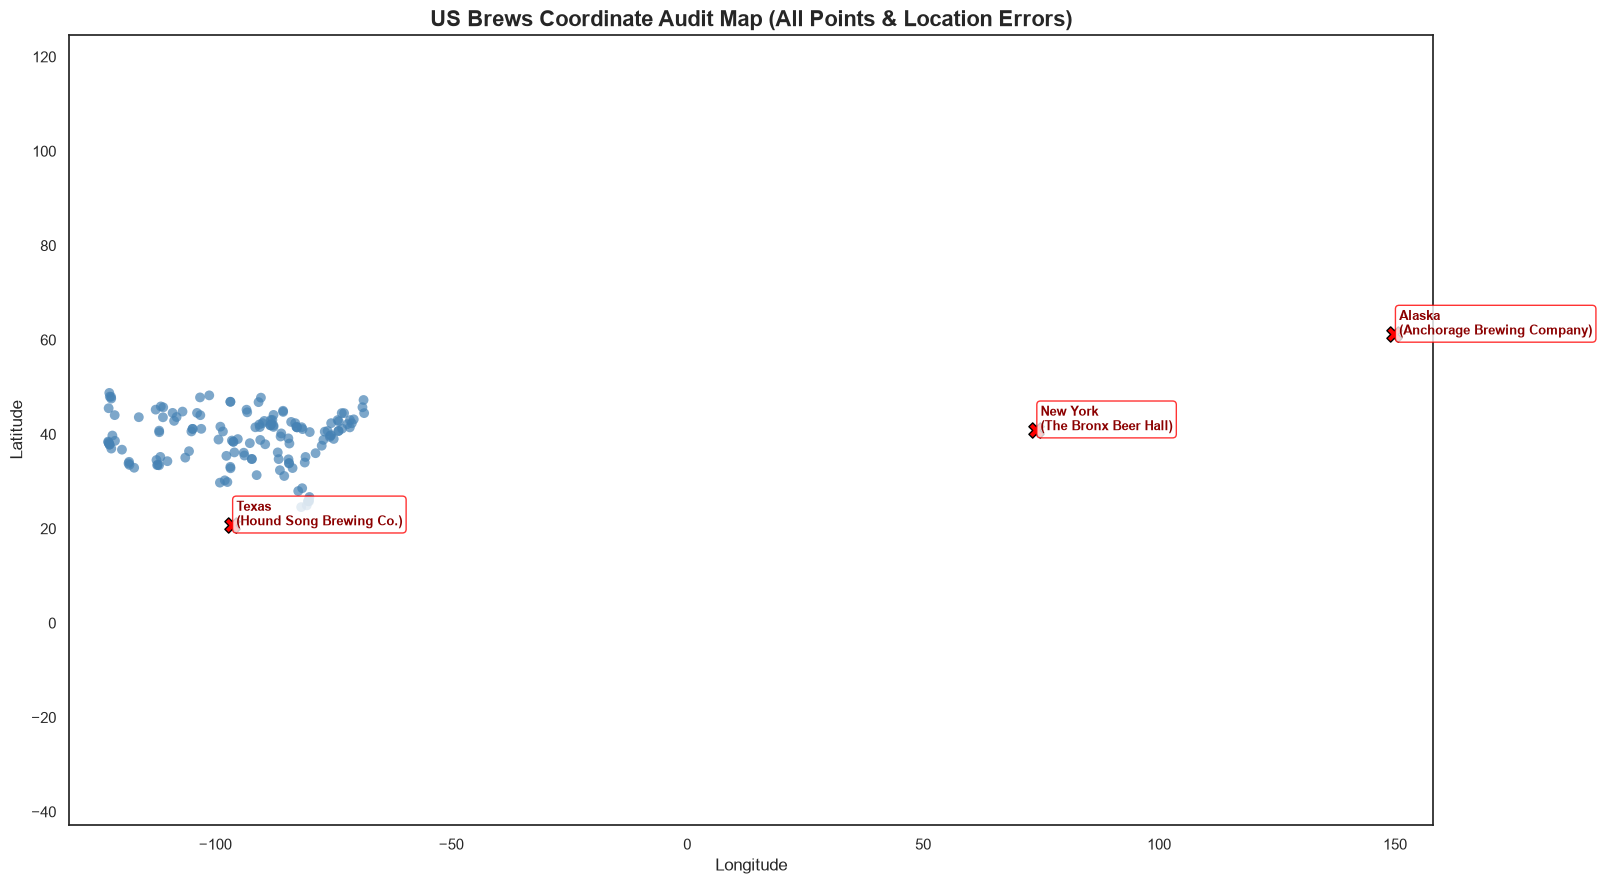

Audit Summary: 146 points within valid US bounds, 3 points flagged outside bounds.


In [4]:
plt.figure(figsize=(16, 9))

# 1. Define valid US geographic boundaries (inclusive of Alaska & Hawaii)
# Valid Lat: ~18 to 72, Valid Lon: ~-180 to -65 (Must be negative in the Western Hemisphere)
valid_us = (
    (df['latitude'] >= 24.0) & 
    (df['latitude'] <= 50.0) & 
    (df['longitude'] >= -125.0) & 
    (df['longitude'] <= -66.0)
)

df_valid = df[valid_us]
df_invalid = df[~valid_us]

# 2. Plot valid US breweries
sns.scatterplot(
    data=df_valid,
    x="longitude",
    y="latitude",
    color="steelblue",
    alpha=0.7,
    s=50,
    edgecolor="none",
    legend=False
)

# 3. Plot out-of-bounds / error points
if not df_invalid.empty:
    sns.scatterplot(
        data=df_invalid,
        x="longitude",
        y="latitude",
        color="red",
        marker="X",
        s=120,
        edgecolor="black",
        linewidth=1,
        legend=False
    )
    
    # 4. Label out-of-bounds points with their region and brewery name
    for _, row in df_invalid.iterrows():
        label_text = f"{row['region']}\n({row['name']})"
        plt.text(
            row['longitude'] + 1.0,  # Slight offset so text doesn't overlap the marker
            row['latitude'], 
            label_text, 
            fontsize=9, 
            fontweight='bold', 
            color='darkred',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="red", alpha=0.8)
        )

plt.title("US Brews Coordinate Audit Map (All Points & Location Errors)", fontsize=16, fontweight="bold")
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)

# Keep proportions natural but let the limits expand if there are wild outliers
plt.gca().set_aspect('equal', adjustable='datalim')
plt.tight_layout()

plt.show()

print(f"Audit Summary: {len(df_valid)} points within valid US bounds, {len(df_invalid)} points flagged outside bounds.")

In [5]:
import re

def load_resilient_wwbrews(filepath="wwbrews.json"):
    """Safely loads wwbrews.json, recovering from syntax errors if students broke it."""
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            file_content = f.read()
    except FileNotFoundError:
        print(f"Error: Could not find {filepath}")
        return []

    # 1. Try strict JSON load
    try:
        parsed = json.loads(file_content)
        print("JSON Lint: PASSED (Valid JSON)")
        return parsed.get("places", [])
    except json.JSONDecodeError as jde:
        print(f"JSON Lint: FAILED ({jde}). Attempting auto-recovery...")

        # 2. Try cleaning trailing commas before closing brackets/braces
        cleaned_content = re.sub(r',\s*([\]}])', r'\1', file_content)
        try:
            parsed = json.loads(cleaned_content)
            print("JSON Lint: Recovered successfully via trailing comma fix!")
            return parsed.get("places", [])
        except json.JSONDecodeError:
            print("JSON Lint: Auto-recovery failed. Falling back to regex parser...")
            
            # 3. Fallback: Extract key-value pairs block by block using regex
            places = []
            blocks = re.findall(r"\{([^}]+)\}", file_content, re.DOTALL)
            for block in blocks:
                place_dict = {}
                # Find all quoted key-value pairs inside the block
                matches = re.findall(r'"([^"]+)"\s*:\s*"([^"]*)"', block)
                for key, val in matches:
                    place_dict[key] = val
                if place_dict:
                    places.append(place_dict)
                    
            print(f"Regex Fallback: Extracted {len(places)} records despite syntax errors.")
            return places

# Load the data resiliently
places_ww = load_resilient_wwbrews("wwbrews.json")
df_ww = pd.DataFrame(places_ww)

print(f"Successfully loaded {len(df_ww)} worldwide records!")

# Convert coordinate and elevation fields to numeric floats
df_ww["latitude"] = pd.to_numeric(df_ww["latitude"], errors="coerce")
df_ww["longitude"] = pd.to_numeric(df_ww["longitude"], errors="coerce")
df_ww["elevation"] = pd.to_numeric(df_ww["elevation"], errors="coerce")

# Drop any rows with missing coordinates
df_ww = df_ww.dropna(subset=["latitude", "longitude"])

print(f"Successfully loaded {len(df_ww)} valid brewery coordinates!")
print(df_ww.head)

JSON Lint: FAILED (Expecting ',' delimiter: line 87 column 218 (char 16438)). Attempting auto-recovery...
JSON Lint: Auto-recovery failed. Falling back to regex parser...
Regex Fallback: Extracted 139 records despite syntax errors.
Successfully loaded 139 worldwide records!
Successfully loaded 139 valid brewery coordinates!
<bound method NDFrame.head of     units             id team                                         name  \
0      nm       lisyderm  t13                                   Birra Ikon   
1     NaN         ZaleyD  t21                                Tango Brewery   
2     NaN     Moonshammy  t27                         Flying Fox Gastropub   
3     NaN      AliceEnck  t23                             Estrella Andorra   
4     NaN    MistaGoat05  t35        Companhia União de Cervejas de Angola   
..    ...            ...  ...                                          ...   
134   NaN          YL626  t25                 The Brewery | Bonanza Estate   
135   NaN  chelseaHa

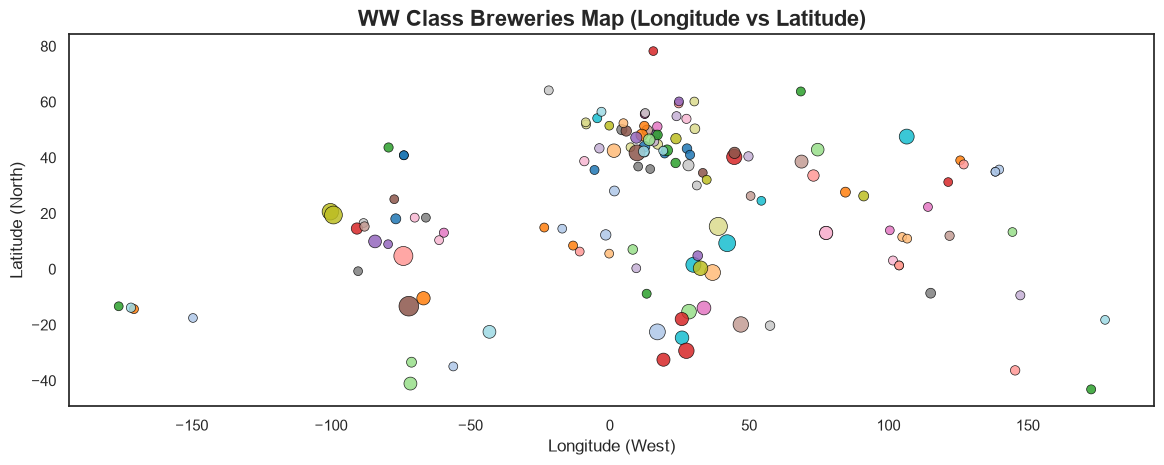

In [6]:
plt.figure(figsize=(14, 8))


ax = sns.scatterplot(
    data=df_ww,
    x="longitude",
    y="latitude",
    hue="country",
    size="elevation",
    sizes=(40, 200),
    palette="tab20",
    alpha=0.85,
    edgecolor="black",
    linewidth=0.5,
    legend=False,
)

plt.title(
    "WW Class Breweries Map (Longitude vs Latitude)", fontsize=16, fontweight="bold"
)
plt.xlabel("Longitude (West)", fontsize=12)
plt.ylabel("Latitude (North)", fontsize=12)

# aspect ratio
ax.set_aspect("equal")

plt.show()

## WORLDWIDE MAP

In [8]:
import folium

# Create a base map centered roughly in the middle of the world
m = folium.Map(location=[20, 0], zoom_start=2)

# Loop through your worldwide dataframe and add pins
for _, row in df_ww.iterrows():
    # Make sure coordinates are valid numbers
    try:
        lat = float(row['latitude'])
        lon = float(row['longitude'])
    except (ValueError, TypeError):
        continue
        
    # Build a comprehensive HTML popup string
    popup_html = f"""
    <div style="font-family: Arial, sans-serif; font-size: 12px; line-height: 1.4; width: 200px;">
        <b style="font-size: 14px; color: #b30000;">{row.get('name', 'Unknown Brewery')}</b><hr style="margin: 4px 0;">
        <b>Country:</b> {row.get('country', 'N/A')}<br>
        <b>Municipality:</b> {row.get('municipality', 'N/A')}<br>
        <b>Elevation:</b> {row.get('elevation', 'N/A')} m<br>
        <b>Team:</b> {row.get('team', 'N/A')}<br>
        <b>ID:</b> {row.get('id', 'N/A')}<br>
        <b>Coords:</b> ({lat:.4f}, {lon:.4f})
    </div>
    """
    
    # Add a marker to the map
    folium.CircleMarker(
        location=[lat, lon],
        radius=6,
        popup=folium.Popup(popup_html, max_width=250),
        color="crimson",
        fill=True,
        fill_color="crimson",
        fill_opacity=0.7
    ).add_to(m)

# Display the interactive map
m